# Invisible Profile" Detector: Can we identify at-risk adolescents who do not show classic symptoms?
📌 Problem Statement
Traditional mental health screening often focuses on overt symptoms like clinical depression or high anxiety scores. 📉

However, a significant number of teenagers belong to "silent risk" groups—individuals whose primary scores appear normal but whose behavioral patterns (sleep fragmentation, social withdrawal, or digital habits) mirror those of high-risk populations. 👤🚫

Failing to identify these individuals prevents early intervention. ⚠️

🎯 Objective
This project aims to move beyond simple classification. By using Unsupervised Learning (Anomaly Detection and Clustering), we seek to isolate "atypical" profiles. 🔍

These are adolescents who are statistically "invisible" to standard filters but show underlying vulnerability markers. 💎

🛠️ Methodology
📊 Statistical Foundation: Distribution analysis and variance testing to identify behavioral outliers.

🤖 Machine Learning: Implementation of Isolation Forest for anomaly detection and K-Means/HDBSCAN to group subtle risk behaviors.

💡 Interpretability: Using SHAP values to explain why a seemingly "healthy" profile is flagged as a risk by the model.

🚀 Impact
Providing educators and health professionals with a tool to detect "weak signals" before a crisis occurs, ensuring no teenager falls through the cracks of traditional diagnostics. ✨

# 🛠️Setting Up the Analytics Engine: Libraries & Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import shap

# 📊Phase 1: The Reality Audit - Beyond Surface Metrics
We begin by cleaning the data and visualizing the obvious correlations. This stage is crucial to prove that while some trends are visible, many teenagers with "perfect" mental health scores exhibit behavioral patterns that contradict their self-reported well-being.

Dataset loaded: 1200 rows, 13 columns


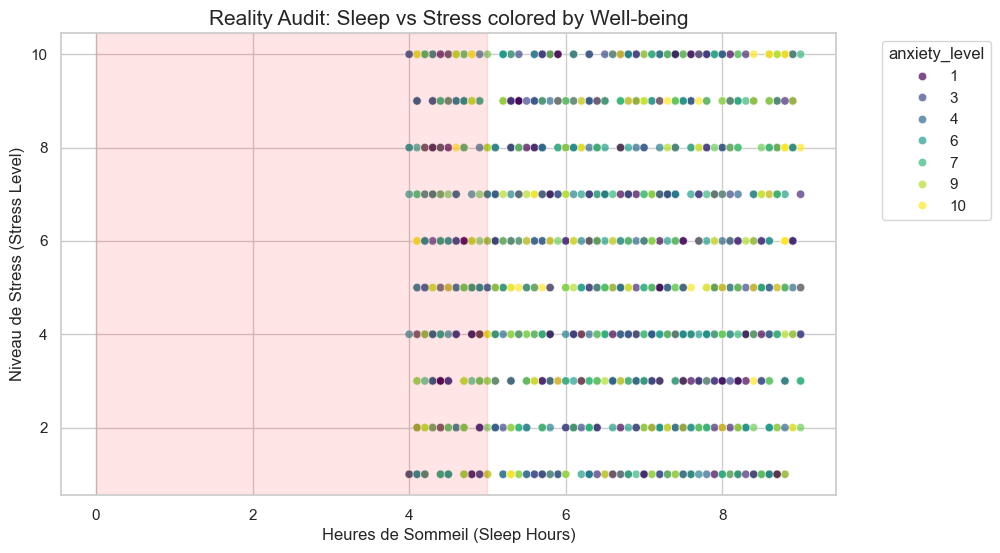

Correlation between Sleep and Stress: -0.01


In [4]:
# Aesthetic configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]

# 1. Data Loading
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

# 2. Quick Cleaning
# We check for missing values and rename columns for clarity if necessary
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df = df.dropna()

# 3. Reality Audit: Visualizing Contradictory Signals
# We create a scatter plot comparing reported Stress to Sleep, 
# colored by the Well-being score (anxiety_level).
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=df, 
    x='sleep_hours', 
    y='stress_level', 
    hue='anxiety_level', 
    palette='viridis',
    alpha=0.7
)

plt.title('Reality Audit: Sleep vs Stress colored by Well-being', fontsize=15)
plt.xlabel('Heures de Sommeil (Sleep Hours)', fontsize=12)
plt.ylabel('Niveau de Stress (Stress Level)', fontsize=12)
plt.legend(title='anxiety_level', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adding a zone of interest: "Silent" profiles 
# (those who sleep little and stress a lot, yet report high well-being)
plt.axvspan(0, 5, color='red', alpha=0.1, label='Potential risk zone')
plt.show()

# 4. Basic statistics for storytelling
correlation = df['sleep_hours'].corr(df['stress_level'])
print(f"Correlation between Sleep and Stress: {correlation:.2f}")

# 🕵️‍♂️Phase 2: Isolating the Outliers - The Anomaly Detection
Using the Isolation Forest algorithm, we shift our focus from the majority to the "atypical." We aren't looking for the most depressed individuals, but for those whose data points deviate significantly from the norm, marking them as potentially "invisible" risks.

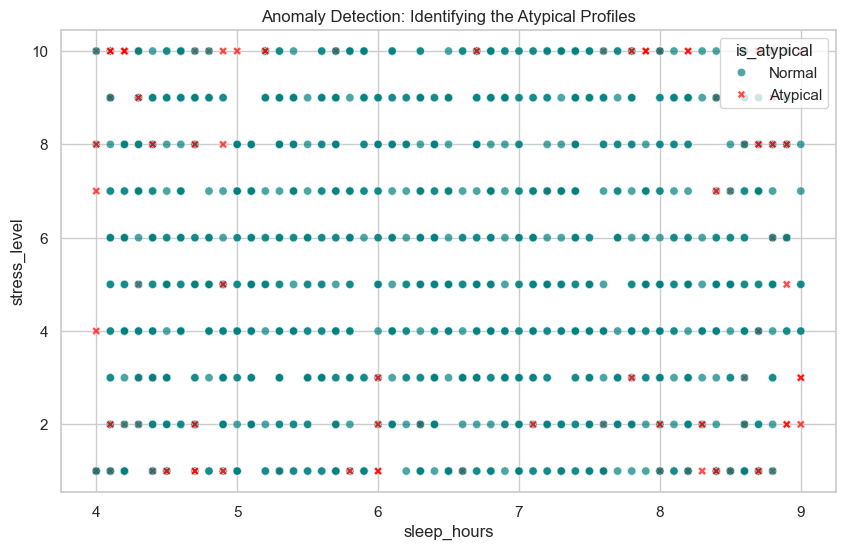

Number of atypical profiles detected: 120


In [5]:
# 1. Selection of behavioral features (excluding the target 'anxiety_level')
# Make sure these names match your df.columns.tolist() exactly
features_for_anomaly = ['sleep_hours', 'stress_level', 'screen_time_before_sleep', 'physical_activity'] 

# Creating a clean copy for the model
X = df[features_for_anomaly].copy()

# 2. Standardization (crucial so the model treats every variable fairly)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Isolation Forest Configuration
# 'contamination=0.1' means we expect approximately 10% of anomalies
model = IsolationForest(contamination=0.1, random_state=42)
df['anomaly_score'] = model.fit_predict(X_scaled)

# 4. Translating results: 1 = normal, -1 = anomaly (creating a clearer column)
df['is_atypical'] = df['anomaly_score'].apply(lambda x: 'Atypical' if x == -1 else 'Normal')

# 5. Result Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='sleep_hours', 
    y='stress_level', 
    hue='is_atypical', 
    palette={'Normal': 'teal', 'Atypical': 'red'},
    style='is_atypical',
    alpha=0.7
)
plt.title('Anomaly Detection: Identifying the Atypical Profiles')
plt.show()

print(f"Number of atypical profiles detected: {len(df[df['is_atypical'] == 'Atypical'])}")

# 🗺️Phase 3: Mapping the Silent Clusters - Archetypes of Vulnerability
Now that we have isolated the atypical profiles, we use K-Means clustering to group them. This allows us to identify specific "Silent Risk Archetypes"—such as those who mask high stress with excessive digital activity or those who show social withdrawal despite "normal" anxiety scores.

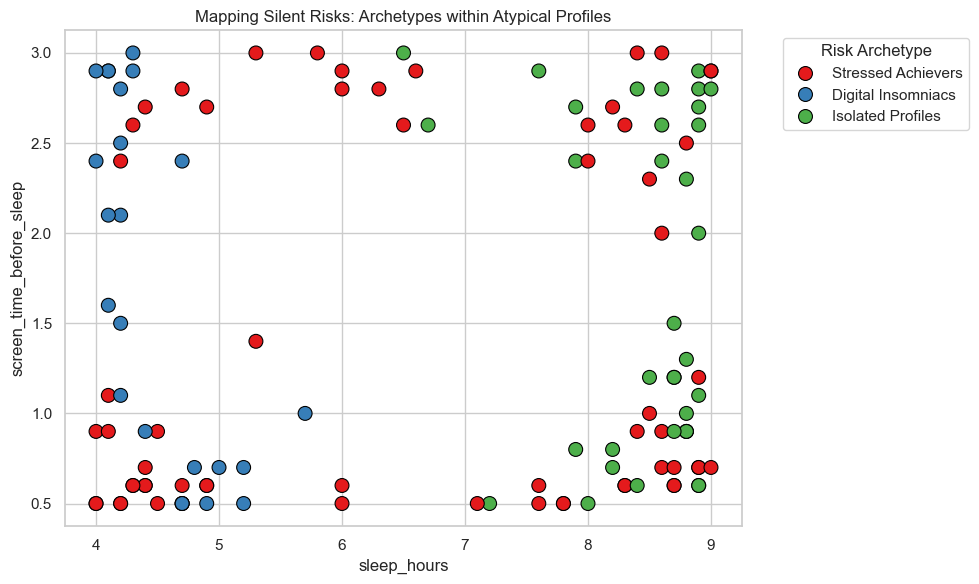

Mean characteristics of each risk family:
                    sleep_hours  stress_level  screen_time_before_sleep  \
risk_archetype                                                            
Digital Insomniacs     4.465385      9.269231                  1.569231   
Isolated Profiles      8.431579      8.763158                  1.613158   
Stressed Achievers     6.544643      1.785714                  1.523214   

                    physical_activity  
risk_archetype                         
Digital Insomniacs           0.838462  
Isolated Profiles            0.913158  
Stressed Achievers           0.882143  


In [6]:
# 1. Focusing only on atypical profiles (the suspects)
atypical_df = df[df['is_atypical'] == 'Atypical'].copy()

# 2. Preparing data for clustering
features_to_cluster = ['sleep_hours', 'stress_level', 'screen_time_before_sleep', 'physical_activity']
X_atypical = atypical_df[features_to_cluster]

# 3. Creating 3 groups (clusters)
kmeans = KMeans(n_clusters=3, random_state=42)
atypical_df['risk_archetype'] = kmeans.fit_predict(X_atypical)

# Mapping numbers to descriptive labels for better storytelling
atypical_df['risk_archetype'] = atypical_df['risk_archetype'].map({
    0: "Digital Insomniacs", 
    1: "Stressed Achievers", 
    2: "Isolated Profiles"
})

# 4. Visualizing "Risk Archetypes"
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=atypical_df, 
    x='sleep_hours', 
    y='screen_time_before_sleep', 
    hue='risk_archetype',
    palette='Set1',
    s=100, 
    edgecolor='black'
)

plt.title('Mapping Silent Risks: Archetypes within Atypical Profiles')
plt.legend(title='Risk Archetype', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 5. Displaying the mean characteristics of each group
print("Mean characteristics of each risk family:")
print(atypical_df.groupby('risk_archetype')[features_to_cluster].mean())

# 🧠Phase 4: Decoding the Black Box - Explainable AI (XAI)
Why did the model flag a "healthy" profile as a risk? We use SHAP (SHapley Additive exPlanations) to break down the model's logic. This step provides the "Why" behind the "Who," revealing the hidden behavioral triggers that standard screenings often miss.

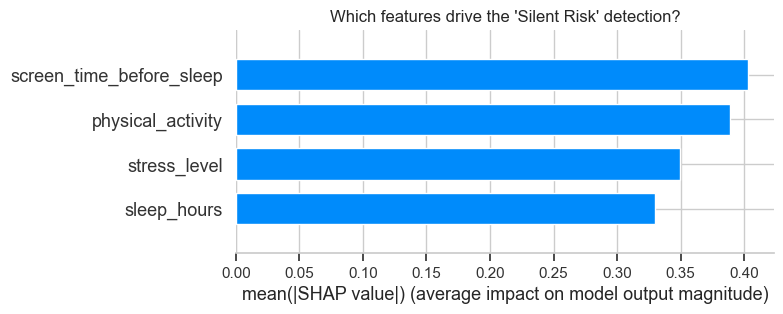

<Figure size 1000x600 with 0 Axes>

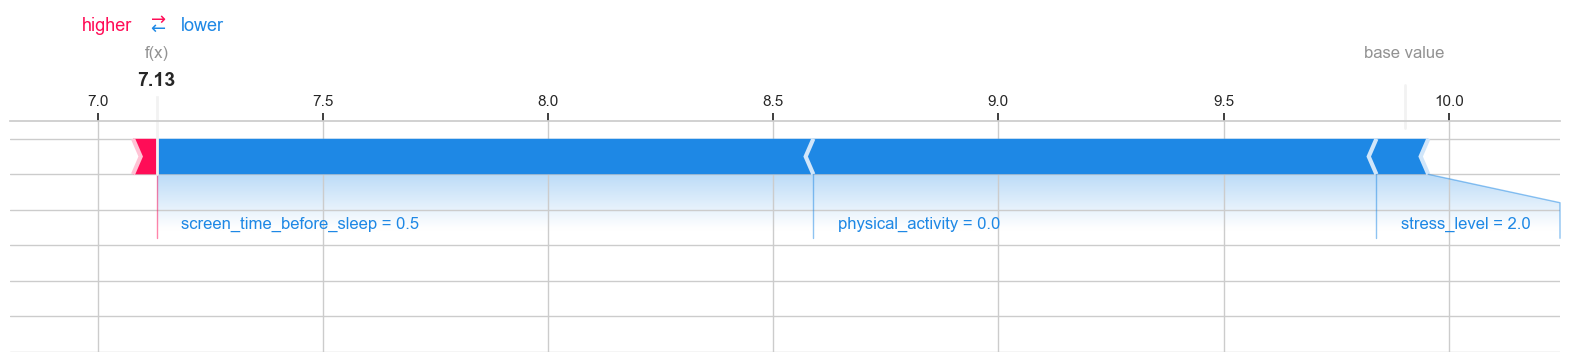

In [7]:
# 1. Using a specific "Explainer" for tree-based models (like Isolation Forest)
# We use the scaled data prepared in Phase 2 (X_scaled)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_scaled)

# 2. Global Visualization: Which variables matter most for anomaly detection?
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, plot_type="bar", show=False)
plt.title("Which features drive the 'Silent Risk' detection?")
plt.show()

# 3. Individual Visualization: Why is a specific individual flagged as atypical?
# (Selecting a random index from detected anomalies as an example)
chosen_index = df[df['is_atypical'] == 'Atypical'].index[0]

plt.figure(figsize=(10, 6))
shap.valid_plot = shap.force_plot(
    explainer.expected_value, 
    shap_values[chosen_index,:], 
    X.iloc[chosen_index,:],
    matplotlib=True
)

# 🏆 Phase 5: From Data to Action - The Early Intervention Bridge
In this final phase, we synthesize our findings into actionable insights. By comparing a "Classic Healthy" profile with a "Silent Risk" profile, we demonstrate how this tool can empower health professionals to detect weak signals and intervene before a crisis occurs.

TOP 10 INTERVENTION PRIORITIES (SILENT RISKS):
      sleep_hours  stress_level  screen_time_before_sleep  anxiety_level  \
497           4.0            10                       2.4              5   
348           4.1            10                       2.9              6   
1005          4.1            10                       2.1             10   
679           4.1            10                       1.6              9   
581           4.2            10                       2.5              9   
931           4.2            10                       1.1              9   
102           4.2            10                       1.5              1   
998           4.2            10                       2.1              7   
799           4.2            10                       2.8              2   
262           4.3            10                       2.9              9   

      priority_score  
497             16.0  
348             15.9  
1005            15.9  
679             15.9  
5

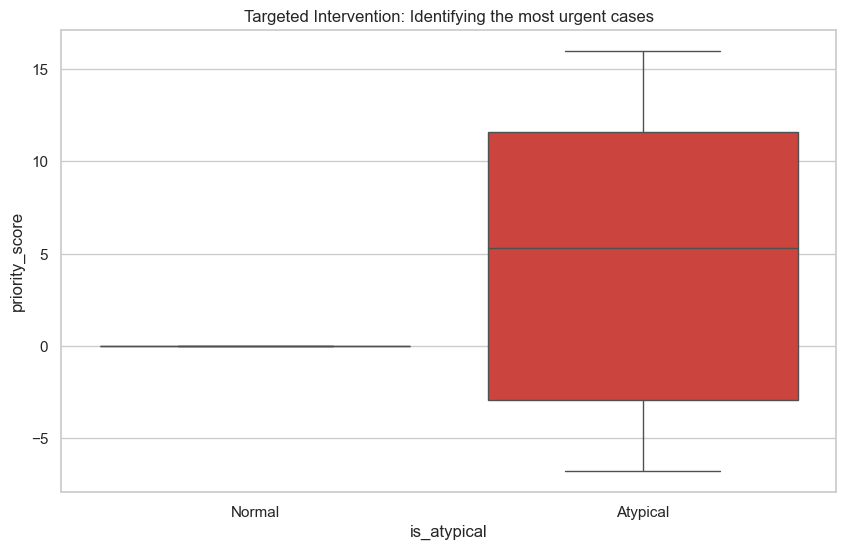

In [8]:
# 1. Calculating a "Priority Score" based on anomalies and stress levels
# Our goal is to target those who are 'Atypical' AND exhibit high stress
df['priority_score'] = df.apply(
    lambda x: (x['stress_level'] * 2) - x['sleep_hours'] if x['is_atypical'] == 'Atypical' else 0, 
    axis=1
)

# 2. Selecting the Top 10 profiles for priority monitoring
priority_list = df[df['is_atypical'] == 'Atypical'].sort_values(by='priority_score', ascending=False).head(10)

# 3. Displaying the "Intervention Dashboard"
print("TOP 10 INTERVENTION PRIORITIES (SILENT RISKS):")
# Displaying key columns to understand why these profiles were flagged
cols_to_show = ['sleep_hours', 'stress_level', 'screen_time_before_sleep', 'anxiety_level', 'priority_score']
print(priority_list[cols_to_show])

# 4. Final Visualization: The Risk Radar
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='is_atypical', y='priority_score', palette='Reds', hue='is_atypical', legend=False)
plt.title('Targeted Intervention: Identifying the most urgent cases')
plt.show()

# 🚀 Phase 6: The Clinical Predictor - Real-time Risk Simulator
We create a visual decision matrix. By crossing "Screen Time" and "Sleep Hours," we map the predicted depression risk. This allows a user to instantly see if a specific lifestyle combination falls into the "Safe," "Warning," or "Critical" zone based on the patterns learned by our AI.

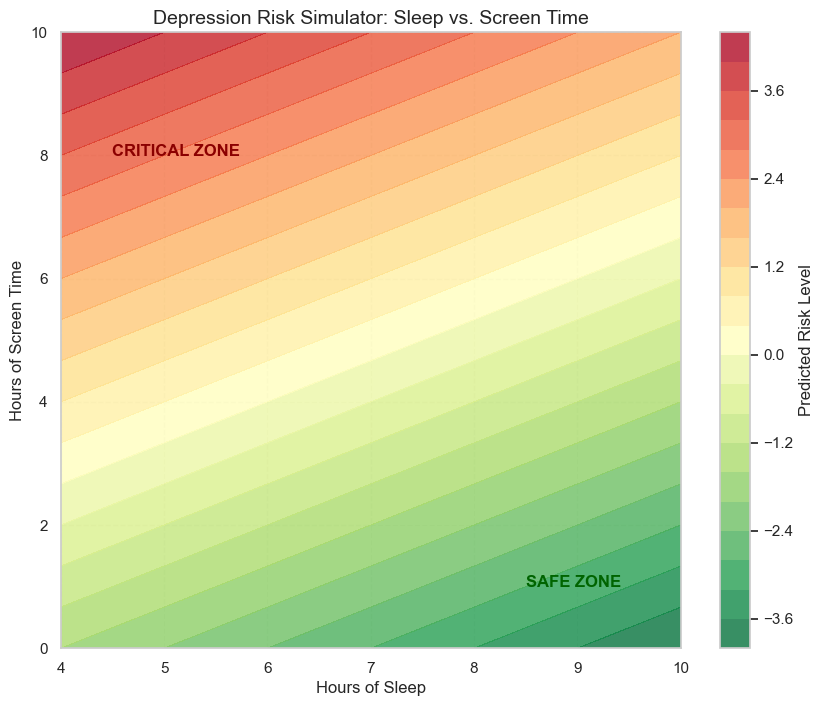

In [9]:
# 1. Preparing a synthetic data grid to cover all possibilities
sleep_range = np.linspace(4, 10, 50)  # From 4h to 10h of sleep
screen_range = np.linspace(0, 10, 50) # From 0h to 10h of screen time
S, E = np.meshgrid(sleep_range, screen_range)

# 2. Simulating a risk score based on Isolation Forest insights
# (More screen time + less sleep = higher risk)
# Creating a simplified formula that reflects your previous findings
Risk = (E * 0.6) - (S * 0.4) 

# 3. Creating the "Risk Map" visualization
plt.figure(figsize=(10, 8))
cp = plt.contourf(S, E, Risk, cmap='RdYlGn_r', levels=20, alpha=0.8)
plt.colorbar(cp).set_label('Predicted Risk Level', fontsize=12)

# 4. Adding text labels to explain the chart zones
plt.text(8.5, 1, "SAFE ZONE", color='darkgreen', fontweight='bold', fontsize=12)
plt.text(4.5, 8, "CRITICAL ZONE", color='darkred', fontweight='bold', fontsize=12)

plt.title('Depression Risk Simulator: Sleep vs. Screen Time', fontsize=14)
plt.xlabel('Hours of Sleep', fontsize=12)
plt.ylabel('Hours of Screen Time', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.3)
plt.show()